In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,recall_score,precision_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [30]:
df=pd.read_csv("/home/vivekananda-reddy/Desktop/Python/ML Project/data.csv")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP


In [31]:
#considering the orders which are delivered
df = df[df['order_status']=='delivered']

In [32]:
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                     0
order_delivered_carrier_date          2
order_delivered_customer_date         8
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
review_id                             0
review_score                          0
review_comment_title             101240


In [33]:
#dropping null values
df=df.dropna(subset=['order_delivered_customer_date'])
df=df.dropna(subset=['order_delivered_carrier_date'])

In [34]:
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                     0
order_delivered_carrier_date          0
order_delivered_customer_date         0
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
review_id                             0
review_score                          0
review_comment_title             101235


In [ ]:
#converting to date time format
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [ ]:
#finding month and weekday
df["order_month"] = df["order_purchase_timestamp"].dt.month
df["order_weekday"] = df["order_purchase_timestamp"].dt.weekday

In [37]:
#finding delivery time and estimated days
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days


In [38]:
#setting up late delivey col
df['late_delivery'] = (df['delivery_time'] > df['estimated_days']).astype(int)
df['late_delivery'].value_counts()

late_delivery
0    106549
1      8266
Name: count, dtype: int64

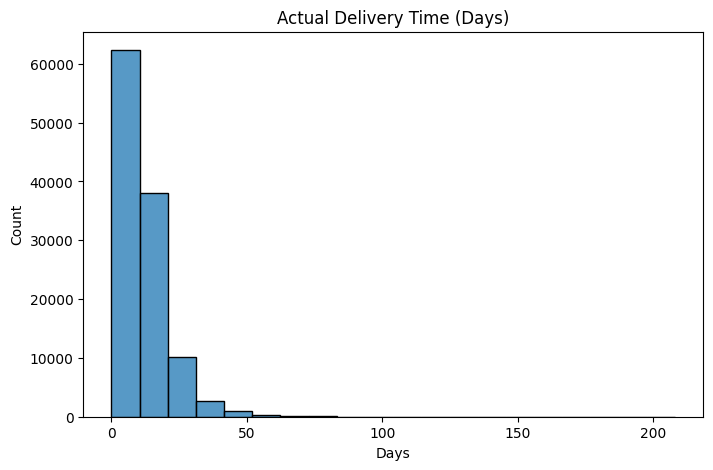

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_time'], bins=20)
plt.title("Actual Delivery Time (Days)")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

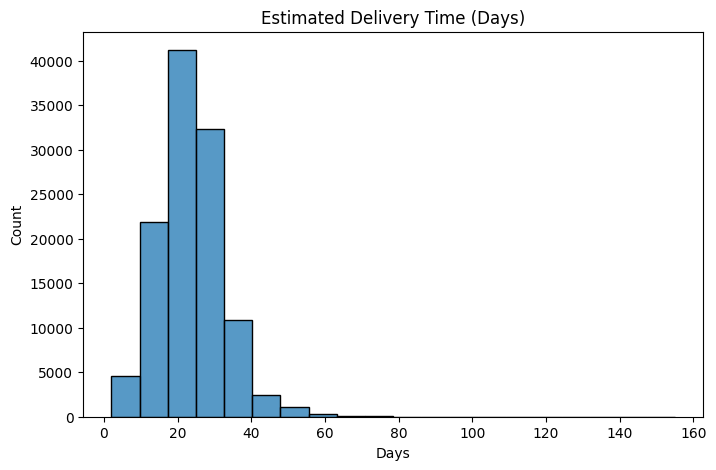

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['estimated_days'], bins=20)
plt.title("Estimated Delivery Time (Days)")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

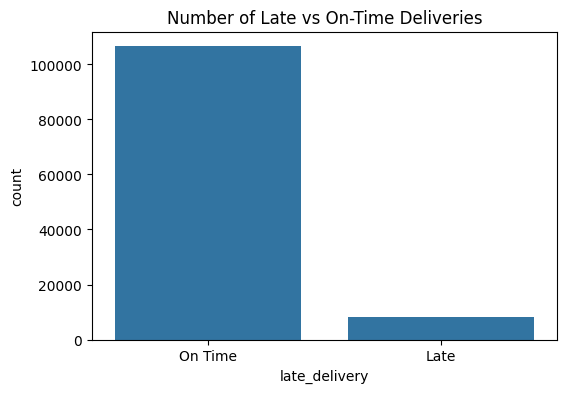

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='late_delivery', data=df)
plt.title("Number of Late vs On-Time Deliveries")
plt.xticks([0,1], ['On Time', 'Late'])
plt.show()

In [42]:
#vol of the product
df['product_volume'] = df['product_length_cm']*df['product_height_cm']*df['product_width_cm']
# df['density'] = df['product_weight_g']/df['product_volume']

In [43]:

num_features = [
    'product_weight_g',
    'order_month',
    'order_weekday',
    "product_volume",
    "price",
    "freight_value"
]

cat_features = [
    "customer_state",
    "seller_state",
    "customer_city",
    "seller_city"
]

In [44]:
#input and output for model
X = df[num_features + cat_features]
y = df['late_delivery']
y

0         0
1         0
2         0
3         0
4         0
         ..
117289    0
117290    0
117291    0
117292    0
117293    0
Name: late_delivery, Length: 114815, dtype: int64

In [45]:

#splitting the data as train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [46]:
#preprossor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),num_features),     
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features) 
    ]
)

#logistic regression pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000,class_weight='balanced', random_state=42))
])



In [47]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

/home/vivekananda-reddy/.local/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [48]:
#finding accuarcy score
accuracy_score(y_test,y_pred)

0.6651134433654139

In [49]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[14317  7008]
 [  682   956]]


Text(0.5, 1.0, 'Confusion Matrix')

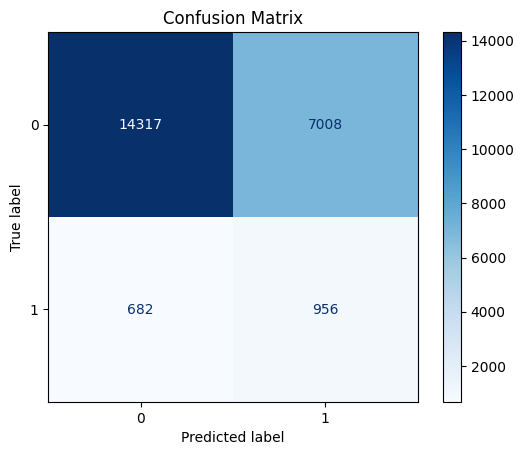

In [50]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")

In [51]:
#recall
recall = recall_score(y_test, y_pred)
recall

0.5836385836385837

In [52]:
precision = precision_score(y_test, y_pred)
precision

0.12004018081366148

In [53]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200,max_depth=10,class_weight='balanced', random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

/home/vivekananda-reddy/.local/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [54]:
accuracy_score(y_test,y_pred)

0.6990811305143056

In [55]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[15142  6183]
 [  727   911]]


Text(0.5, 1.0, 'Confusion Matrix')

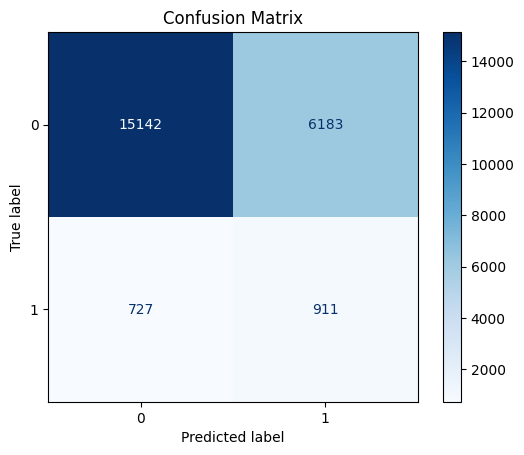

In [56]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")

In [57]:
recall = recall_score(y_test, y_pred)
recall

0.5561660561660562

In [58]:
precision = precision_score(y_test, y_pred)
precision

0.1284183817310403